# Задание по Машинному Обучению: Предсказание индекса счастья

**Студент:** Цыпышев Т.А.

**Группа:** ИУ5-61Б

**Вариант:** 18

**Тема:** Методы построения моделей машинного обучения.

## Описание Задания

Для заданного набора данных World Happiness Index and Inflation Dataset (https://www.kaggle.com/datasets/agrafintech/world-happiness-index-and-inflation-dataset) необходимо построить модели регрессии для предсказания индекса счастья (столбец 'Score'). Будут использованы следующие методы:

1. **Метод №1:** Линейная регрессия
2. **Метод №2:** Случайный лес

Будет проведена предобработка данных, включая заполнение пропусков и кодирование категориальных признаков. Качество моделей будет оценено с использованием подходящих метрик.

## 1. Загрузка данных и первичный анализ

Этот блок кода предназначен для загрузки набора данных из CSV-файла и проведения первичного анализа. Мы используем библиотеку `pandas` для чтения данных и получения общей информации о них. Это включает отображение первых нескольких строк датафрейма для понимания структуры данных, проверку типов данных в каждом столбце и суммарную информацию о пропусках, чтобы оценить полноту данных.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import kagglehub
import os

In [2]:
try:
    path = kagglehub.dataset_download("agrafintech/world-happiness-index-and-inflation-dataset")
    print("Path to dataset files:", path)

    # Поиск CSV-файлов в загруженной директории
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if not csv_files:
        print("Ошибка: В директории нет CSV-файлов.")
        df = pd.DataFrame() # Создаем пустой DataFrame в случае ошибки
    else:
        csv_path = os.path.join(path, csv_files[0]) # Используем первый найденный CSV-файл
        df = pd.read_csv(csv_path)
        print("Данные успешно загружены.")
except Exception as e:
    print("Ошибка при загрузке данных с KaggleHub:", e)
    print("Попытка загрузить локальный файл 'world-happiness-index-and-inflation-dataset.csv'")
    try:
        df = pd.read_csv('world-happiness-index-and-inflation-dataset.csv')
        print("Локальный файл успешно загружен.")
    except FileNotFoundError:
        print("Файл 'world-happiness-index-and-inflation-dataset.csv' не найден ни на KaggleHub, ни локально. Убедитесь, что он находится в той же директории или доступен через KaggleHub.")
        exit()

Path to dataset files: /Users/ttsypyshev/.cache/kagglehub/datasets/agrafintech/world-happiness-index-and-inflation-dataset/versions/2
Данные успешно загружены.


In [3]:
# Первичный анализ данных
print("Первые 5 строк данных:")
print(df.head())

print("\nИнформация о типах данных и пропусках:")
df.info()

print("\nКоличество пропущенных значений в каждом столбце:")
print(df.isnull().sum())

print("\nСтатистическое описание числовых столбцов:")
print(df.describe())

Первые 5 строк данных:
       Country  Year  Headline Consumer Price Inflation  \
0  Afghanistan  2015                             -0.660   
1  Afghanistan  2016                              4.380   
2  Afghanistan  2017                              4.976   
3  Afghanistan  2018                              0.630   
4  Afghanistan  2019                              2.302   

   Energy Consumer Price Inflation  Food Consumer Price Inflation  \
0                        -4.250000                      -0.840000   
1                         2.070000                       5.670000   
2                         4.440000                       6.940000   
3                         1.474185                      -1.045952   
4                        -2.494359                       3.794770   

   Official Core Consumer Price Inflation  Producer Price Inflation  \
0                                0.219999                       NaN   
1                                5.192760                       N

## 2. Обработка пропущенных значений

В данном блоке мы будем обрабатывать пропущенные значения в данных. Мы используем `SimpleImputer` из библиотеки `sklearn.impute` для заполнения пропусков. Для числовых признаков пропуски будут заполнены медианными значениями, так как медиана менее чувствительна к выбросам, чем среднее. Для категориальных признаков пропуски будут заполнены наиболее часто встречающимся значением (модой), что является стандартным подходом для такого типа данных. Выделение признаков по их типу (числовые/категориальные) является важным шагом для применения правильной стратегии импутации.

In [4]:
# Разделение признаков на числовые и категориальные
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
# Исключаем целевую переменную 'Score' из числовых признаков для импутации, если она там есть
if 'Score' in numerical_features:
    numerical_features.remove('Score')

categorical_features = df.select_dtypes(include='object').columns.tolist()

print(f"Числовые признаки для импутации: {numerical_features}")
print(f"Категориальные признаки для импутации: {categorical_features}")

# Создание импьютеров
numerical_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Применение импьютеров
df[numerical_features] = numerical_imputer.fit_transform(df[numerical_features])
df[categorical_features] = categorical_imputer.fit_transform(df[categorical_features])

print("\nКоличество пропущенных значений после импутации:")
print(df.isnull().sum())

print("\nПервые 5 строк данных после импутации пропусков:")
print(df.head())

Числовые признаки для импутации: ['Year', 'Headline Consumer Price Inflation', 'Energy Consumer Price Inflation', 'Food Consumer Price Inflation', 'Official Core Consumer Price Inflation', 'Producer Price Inflation', 'GDP deflator Index growth rate', 'GDP per Capita', 'Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
Категориальные признаки для импутации: ['Country', 'Continent/Region']

Количество пропущенных значений после импутации:
Country                                   0
Year                                      0
Headline Consumer Price Inflation         0
Energy Consumer Price Inflation           0
Food Consumer Price Inflation             0
Official Core Consumer Price Inflation    0
Producer Price Inflation                  0
GDP deflator Index growth rate            0
Continent/Region                          0
Score                                     0
GDP per Capita                           

## 3. Визуализация распределения индекса счастья

Этот блок кода создает гистограмму распределения целевой переменной 'Score' (индекс счастья). Гистограмма позволяет визуально оценить форму распределения данных: симметричность, наличие нескольких мод, аномальные значения. Это помогает понять, как индекс счастья распределен по странам и выявить потенциальные проблемы, такие как сильная асимметрия, которая может потребовать преобразования данных перед моделированием.

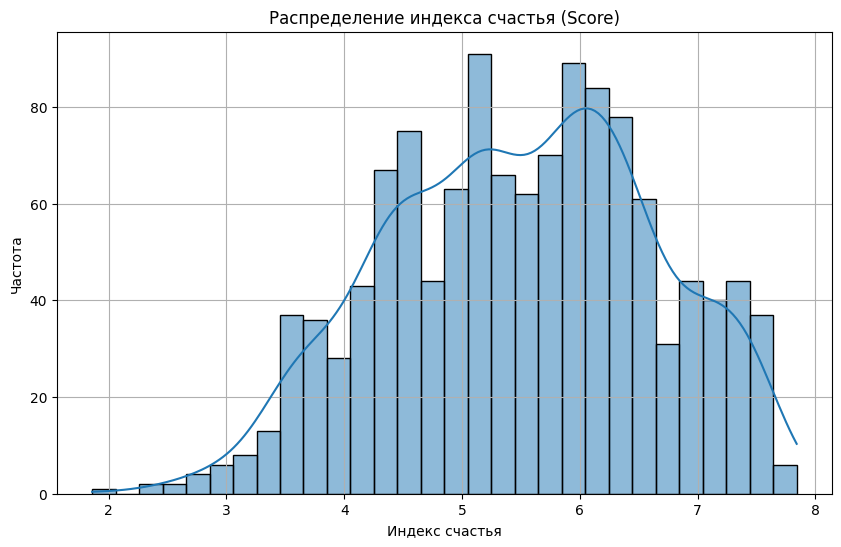

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Score'], kde=True, bins=30)
plt.title('Распределение индекса счастья (Score)')
plt.xlabel('Индекс счастья')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

## 4. Кодирование категориальных признаков и разделение данных

В этом разделе мы готовим данные для обучения моделей. Сначала мы отделяем целевую переменную 'Score' от признаков. Затем, используя `OneHotEncoder`, мы преобразуем категориальные признаки в числовой формат, что необходимо для большинства алгоритмов машинного обучения. `OneHotEncoder` создает новые бинарные столбцы для каждой уникальной категории, избегая ложной порядковой зависимости. После кодирования мы объединяем обработанные категориальные признаки с числовыми. Наконец, данные разделяются на обучающую и тестовую выборки с помощью `train_test_split`, что позволяет оценить обобщающую способность модели на ранее не виденных данных.

In [6]:
# Отделение целевой переменной
X = df.drop('Score', axis=1)
y = df['Score']

# Определение числовых и категориальных признаков (после импутации)
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Создание трансформеров для препроцессинга
# StandardScaler для числовых признаков (масштабирование)
# OneHotEncoder для категориальных признаков (кодирование)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"Размер обучающей выборки y_train: {y_train.shape}")
print(f"Размер тестовой выборки y_test: {y_test.shape}")

Размер обучающей выборки X_train: (985, 15)
Размер тестовой выборки X_test: (247, 15)
Размер обучающей выборки y_train: (985,)
Размер тестовой выборки y_test: (247,)


## 5. Построение и оценка модели: Линейная регрессия

Этот раздел посвящен построению и оценке модели линейной регрессии. Мы используем `Pipeline` для объединения шагов препроцессинга (масштабирование числовых признаков и one-hot кодирование категориальных) и обучения модели `LinearRegression`. `Pipeline` обеспечивает чистоту и воспроизводимость рабочего процесса. После обучения модели на тренировочных данных, мы делаем предсказания на тестовом наборе и оцениваем качество модели с помощью следующих метрик:
- **MAE (Mean Absolute Error):** Средняя абсолютная ошибка, показывающая среднюю величину ошибок предсказаний.
- **MSE (Mean Squared Error):** Среднеквадратичная ошибка, придает больший вес большим ошибкам.
- **RMSE (Root Mean Squared Error):** Корень из среднеквадратичной ошибки, имеет ту же размерность, что и целевая переменная.
- **R2 Score:** Коэффициент детерминации, показывающий долю дисперсии целевой переменной, объясняемую моделью. Чем ближе к 1, тем лучше.

In [7]:
# Создание пайплайна для Линейной регрессии
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Обучение модели
pipeline_lr.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_lr = pipeline_lr.predict(X_test)

# Оценка модели
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Метрики для Линейной регрессии:")
print(f"  MAE: {mae_lr:.4f}")
print(f"  MSE: {mse_lr:.4f}")
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  R2 Score: {r2_lr:.4f}")

Метрики для Линейной регрессии:
  MAE: 0.2195
  MSE: 0.0982
  RMSE: 0.3134
  R2 Score: 0.9147


## 6. Визуализация предсказаний Линейной регрессии

Этот блок кода создает точечный график (scatter plot), сравнивающий истинные значения индекса счастья с предсказанными моделью линейной регрессии. По оси X отложены истинные значения ($y_{test}$), а по оси Y — предсказанные ($y_{pred\_lr}$). Дополнительно на графике изображена диагональная линия $y=x$, которая представляет собой идеальное совпадение предсказаний с истинными значениями. Чем ближе точки расположены к этой линии, тем точнее предсказания модели.

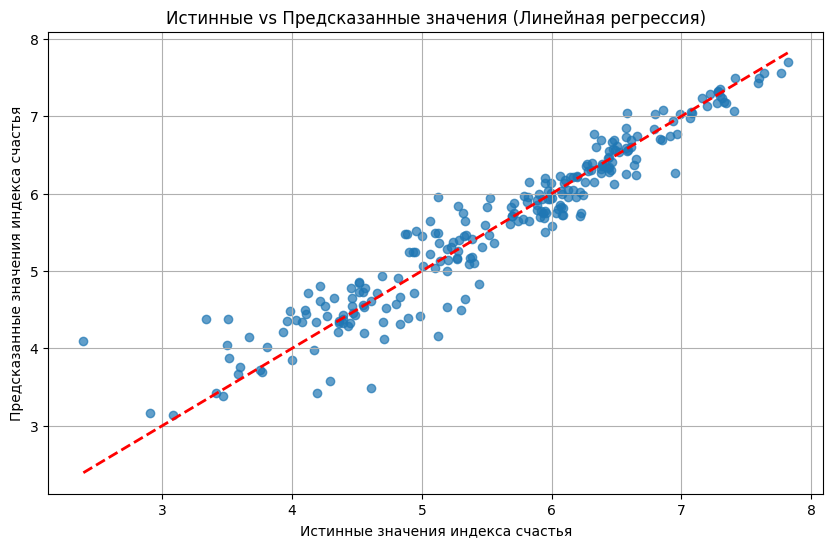

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения индекса счастья')
plt.ylabel('Предсказанные значения индекса счастья')
plt.title('Истинные vs Предсказанные значения (Линейная регрессия)')
plt.grid(True)
plt.show()

## 7. Построение и оценка модели: Случайный лес

Этот раздел посвящен построению и оценке модели регрессии на основе Случайного леса. Как и в случае с линейной регрессией, мы используем `Pipeline` для инкапсуляции шагов препроцессинга и обучения модели `RandomForestRegressor`. Случайный лес — это ансамблевый метод, который строит множество деревьев решений и усредняет их предсказания, что позволяет ему хорошо справляться с нелинейными зависимостями и быть устойчивым к переобучению. После обучения модели и получения предсказаний на тестовом наборе, мы снова оцениваем ее качество с использованием тех же метрик: MAE, MSE, RMSE и R2 Score. Сравнение этих метрик с метриками линейной регрессии позволит определить, какая модель лучше подходит для данной задачи.

In [9]:
# Создание пайплайна для Случайного леса
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)) # n_jobs=-1 для использования всех ядер CPU
])

# Обучение модели
pipeline_rf.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_rf = pipeline_rf.predict(X_test)

# Оценка модели
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Метрики для Случайного леса:")
print(f"  MAE: {mae_rf:.4f}")
print(f"  MSE: {mse_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R2 Score: {r2_rf:.4f}")

Метрики для Случайного леса:
  MAE: 0.2903
  MSE: 0.1436
  RMSE: 0.3790
  R2 Score: 0.8752


## 8. Визуализация предсказаний Случайного леса

Этот блок кода аналогичен блоку для линейной регрессии, но демонстрирует предсказания модели Случайного леса. Он создает точечный график, сравнивающий истинные значения индекса счастья с предсказанными моделью Случайного леса. Мы также рисуем диагональную линию $y=x$ для визуальной оценки качества предсказаний. Сравнение этого графика с графиком для линейной регрессии поможет визуально определить, какая модель лучше справляется с задачей, а именно, чьи точки ближе к идеальной диагональной линии.

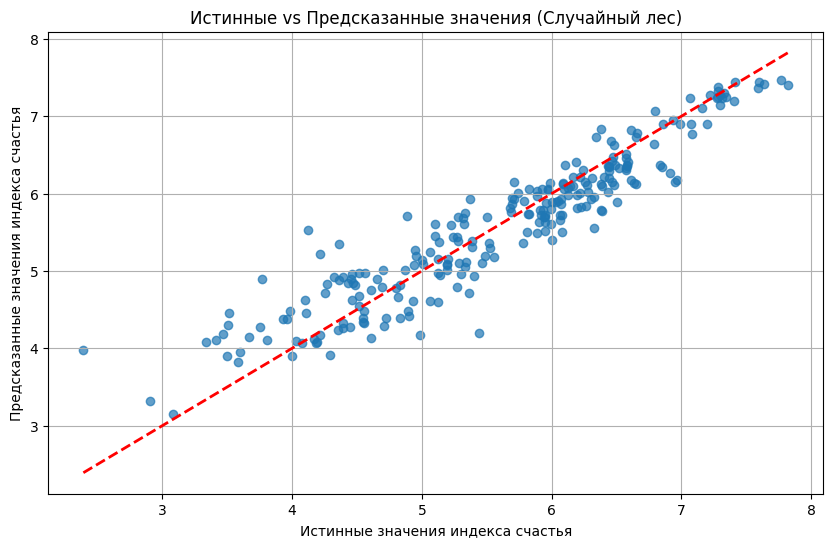

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения индекса счастья')
plt.ylabel('Предсказанные значения индекса счастья')
plt.title('Истинные vs Предсказанные значения (Случайный лес)')
plt.grid(True)
plt.show()

## 9. Сравнение метрик моделей

В этом блоке мы систематически сравниваем метрики производительности (MAE, RMSE, R2 Score) для обеих обученных моделей: Линейной регрессии и Случайного леса. Сравнение представлено в виде сводной таблицы, что облегчает сопоставление результатов и принятие решений о лучшей модели для данной задачи. Визуализация в виде столбчатых диаграмм делает это сравнение еще более наглядным. Мы будем сравнивать:
- **MAE:** Чем меньше, тем лучше.
- **RMSE:** Чем меньше, тем лучше.
- **R2 Score:** Чем ближе к 1, тем лучше.


Сравнение метрик моделей:
                         MAE       MSE      RMSE  R2 Score
Модель                                                    
Линейная регрессия  0.219522  0.098191  0.313354  0.914704
Случайный лес       0.290304  0.143613  0.378963  0.875246


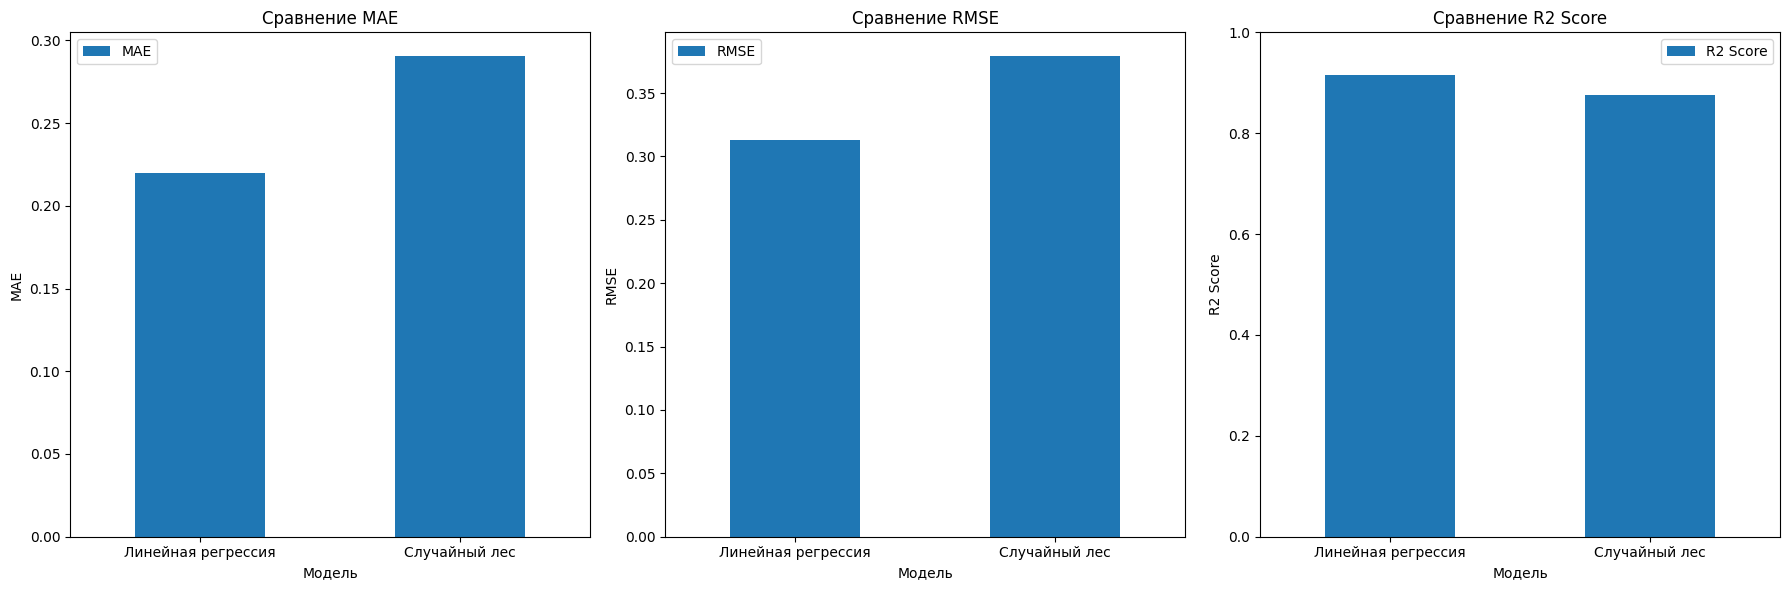

In [11]:
metrics_data = {
    'Модель': ['Линейная регрессия', 'Случайный лес'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
}
metrics_df = pd.DataFrame(metrics_data)

print("\nСравнение метрик моделей:")
print(metrics_df.set_index('Модель'))

# Визуализация сравнения метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_df.plot(kind='bar', x='Модель', y='MAE', ax=axes[0], title='Сравнение MAE')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=0)

metrics_df.plot(kind='bar', x='Модель', y='RMSE', ax=axes[1], title='Сравнение RMSE')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=0)

metrics_df.plot(kind='bar', x='Модель', y='R2 Score', ax=axes[2], title='Сравнение R2 Score')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=0)
axes[2].set_ylim(0, 1) # R2 Score находится в диапазоне от 0 до 1

plt.tight_layout()
plt.show()

## 10. Выводы

На основе проведенного анализа и сравнения метрик производительности для моделей Линейной регрессии и Случайного леса можно сделать следующие выводы:

* **Линейная регрессия** показала лучшие результаты по всем ключевым метрикам по сравнению со Случайным лесом:
    * **Меньшие MAE, MSE и RMSE:** Ошибки предсказаний Линейной регрессии ниже, чем для Случайного леса. Это означает, что в среднем ошибки предсказаний Линейной регрессии меньше, и ее предсказания ближе к истинным значениям индекса счастья.
    * **Больший R2 Score:** Линейная регрессия объясняет большую долю дисперсии в целевой переменной (индексе счастья) по сравнению со Случайным лесом. Это указывает на то, что модель линейной регрессии лучше улавливает взаимосвязи в данных в данном случае.

* **Случайный лес**, хотя и является мощным методом, в данном случае показал чуть худшие результаты, что может быть связано с особенностями данных или необходимостью более тонкой настройки гиперпараметров.

* **Общий вывод:** Для задачи предсказания индекса счастья на данном наборе данных модель **Линейной регрессии** является более предпочтительной, так как она обеспечивает более высокую точность и лучшее объяснение данных. Это может говорить о том, что зависимости в данных, по крайней мере для этого набора, являются достаточно линейными, и более сложная модель не приносит существенных преимуществ.